<a href="https://colab.research.google.com/github/harshithanotfound/Plant-Disease-Detection-using-Transfer-Learning-with-ResNet18/blob/main/Plant_Disease_Detection_using_Transfer_Learning_with_ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle -q

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("You are using CPU. Please change runtime to T4 GPU.")

Using device: cuda
GPU Name: Tesla T4


In [3]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harshithaavvaru","key":"1e31cec57285b2a626db5f3683070a6d"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [5]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:33<00:00, 18.9MB/s]



In [6]:
with zipfile.ZipFile("new-plant-diseases-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plant_disease_dataset")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [7]:
base_path = "/content/plant_disease_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

train_dir = os.path.join(base_path, "train")
valid_dir = os.path.join(base_path, "valid")

print("Train folder exists:", os.path.exists(train_dir))
print("Validation folder exists:", os.path.exists(valid_dir))

Train folder exists: True
Validation folder exists: True


In [8]:
selected_classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Potato___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight"
]

print("Selected disease classes:")

for cls in selected_classes:
    print(cls)

Selected disease classes:
Tomato___healthy
Tomato___Early_blight
Tomato___Late_blight
Potato___healthy
Potato___Early_blight
Potato___Late_blight


In [9]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
class FilteredPlantDataset(Dataset):
    def __init__(self, root_dir, selected_classes, transform=None, max_images_per_class=300):
        self.root_dir = root_dir
        self.selected_classes = selected_classes
        self.transform = transform
        self.samples = []

        self.class_to_idx = {
            class_name: index for index, class_name in enumerate(selected_classes)
        }

        for class_name in selected_classes:
            class_path = os.path.join(root_dir, class_name)

            if not os.path.exists(class_path):
                print("Missing folder:", class_path)
                continue

            image_names = os.listdir(class_path)
            image_names = image_names[:max_images_per_class]

            for image_name in image_names:
                image_path = os.path.join(class_path, image_name)

                if image_path.lower().endswith((".jpg", ".jpeg", ".png")):
                    label = self.class_to_idx[class_name]
                    self.samples.append((image_path, label))

        print("Dataset created from:", root_dir)
        print("Total images:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
train_dataset = FilteredPlantDataset(
    root_dir=train_dir,
    selected_classes=selected_classes,
    transform=train_transforms,
    max_images_per_class=300
)

valid_dataset = FilteredPlantDataset(
    root_dir=valid_dir,
    selected_classes=selected_classes,
    transform=valid_transforms,
    max_images_per_class=100
)

class_names = selected_classes
num_classes = len(class_names)

print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Number of classes:", num_classes)

Dataset created from: /content/plant_disease_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Total images: 1800
Dataset created from: /content/plant_disease_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Total images: 600
Training images: 1800
Validation images: 600
Number of classes: 6


In [12]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Train batches: 57
Validation batches: 19


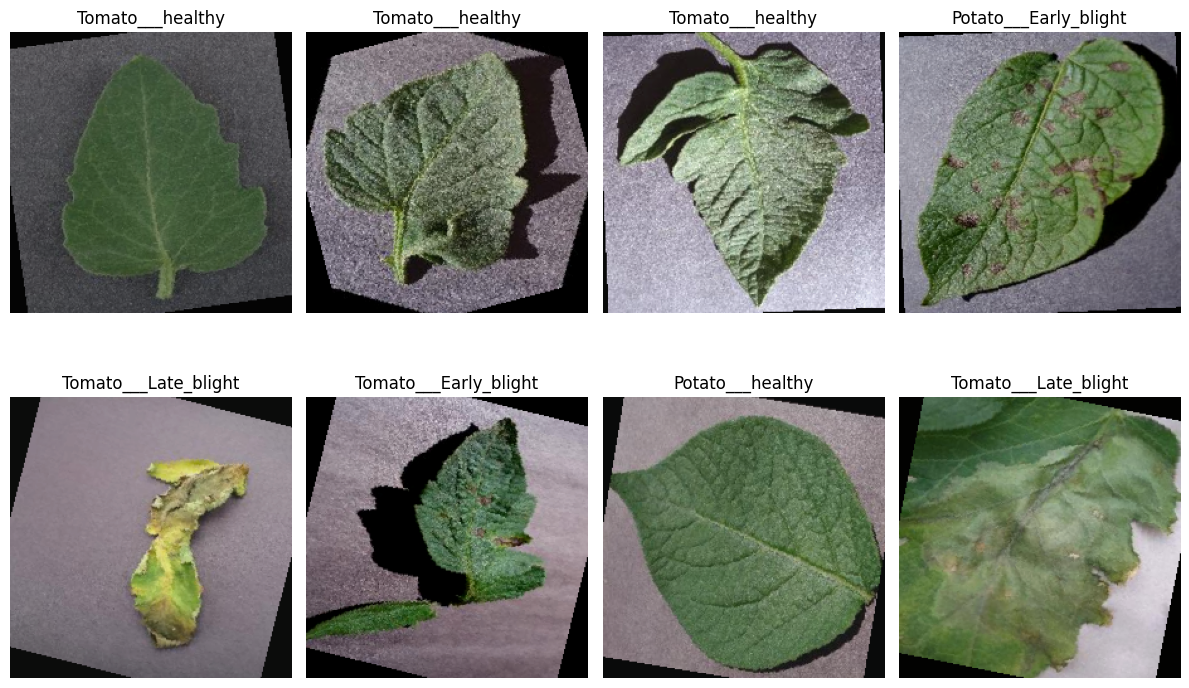

In [13]:
def show_image(image_tensor, title):
    image = image_tensor.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = std * image + mean
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    plt.title(title)
    plt.axis("off")


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    show_image(images[i], class_names[labels[i]])

plt.tight_layout()
plt.show()

In [14]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

model = model.to(device)

print("Pretrained ResNet18 loaded successfully.")
print("Feature layers frozen.")
print("Only final classification layer will be trained.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 224MB/s]


Pretrained ResNet18 loaded successfully.
Feature layers frozen.
Only final classification layer will be trained.


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss function and optimizer created successfully.")

Loss function and optimizer created successfully.


In [16]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs):
    train_losses = []
    valid_losses = []
    train_accuracies = []
    valid_accuracies = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 40)

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for batch_index, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if (batch_index + 1) % 10 == 0:
                print(f"Completed batch {batch_index + 1}/{len(train_loader)}")

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        model.eval()

        valid_running_loss = 0.0
        valid_correct = 0
        valid_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                valid_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                valid_total += labels.size(0)
                valid_correct += (predicted == labels).sum().item()

        valid_loss = valid_running_loss / len(valid_loader)
        valid_accuracy = 100 * valid_correct / valid_total

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accuracies.append(train_accuracy)
        valid_accuracies.append(valid_accuracy)

        print("Training Loss:", round(train_loss, 4))
        print("Training Accuracy:", round(train_accuracy, 2), "%")
        print("Validation Loss:", round(valid_loss, 4))
        print("Validation Accuracy:", round(valid_accuracy, 2), "%")

    return train_losses, valid_losses, train_accuracies, valid_accuracies

In [17]:
epochs = 3

train_losses, valid_losses, train_accuracies, valid_accuracies = train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    epochs
)


Epoch 1/3
----------------------------------------
Completed batch 10/57
Completed batch 20/57
Completed batch 30/57
Completed batch 40/57
Completed batch 50/57
Training Loss: 1.2599
Training Accuracy: 58.78 %
Validation Loss: 0.7642
Validation Accuracy: 82.17 %

Epoch 2/3
----------------------------------------
Completed batch 10/57
Completed batch 20/57
Completed batch 30/57
Completed batch 40/57
Completed batch 50/57
Training Loss: 0.6636
Training Accuracy: 84.17 %
Validation Loss: 0.5203
Validation Accuracy: 87.33 %

Epoch 3/3
----------------------------------------
Completed batch 10/57
Completed batch 20/57
Completed batch 30/57
Completed batch 40/57
Completed batch 50/57
Training Loss: 0.4811
Training Accuracy: 89.17 %
Validation Loss: 0.4348
Validation Accuracy: 87.83 %


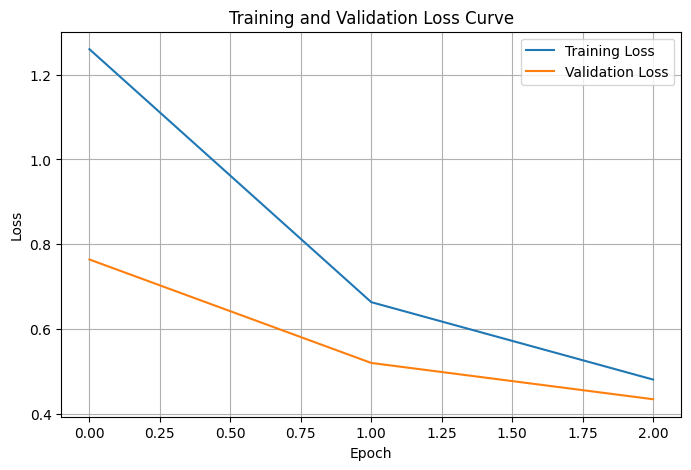

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.savefig("loss_curve.png")
plt.show()

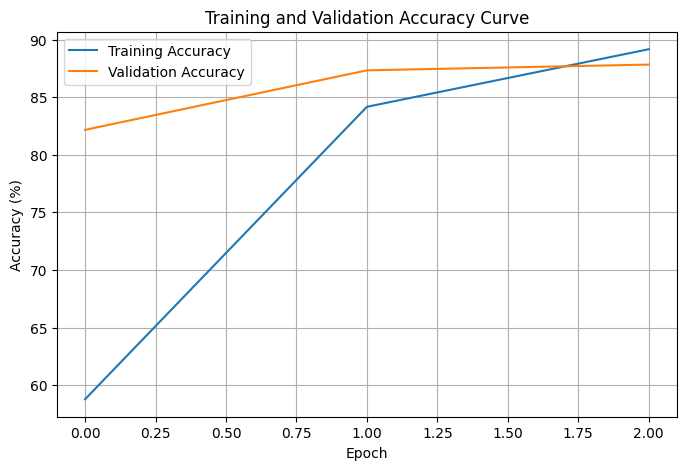

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(valid_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy Curve")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_curve.png")
plt.show()

In [20]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Evaluation completed.")

Evaluation completed.


In [21]:
print("Classification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

Classification Report:
                       precision    recall  f1-score   support

     Tomato___healthy       0.99      0.86      0.92       100
Tomato___Early_blight       0.80      0.82      0.81       100
 Tomato___Late_blight       0.77      0.84      0.80       100
     Potato___healthy       0.92      0.99      0.95       100
Potato___Early_blight       0.97      0.89      0.93       100
 Potato___Late_blight       0.86      0.87      0.87       100

             accuracy                           0.88       600
            macro avg       0.88      0.88      0.88       600
         weighted avg       0.88      0.88      0.88       600



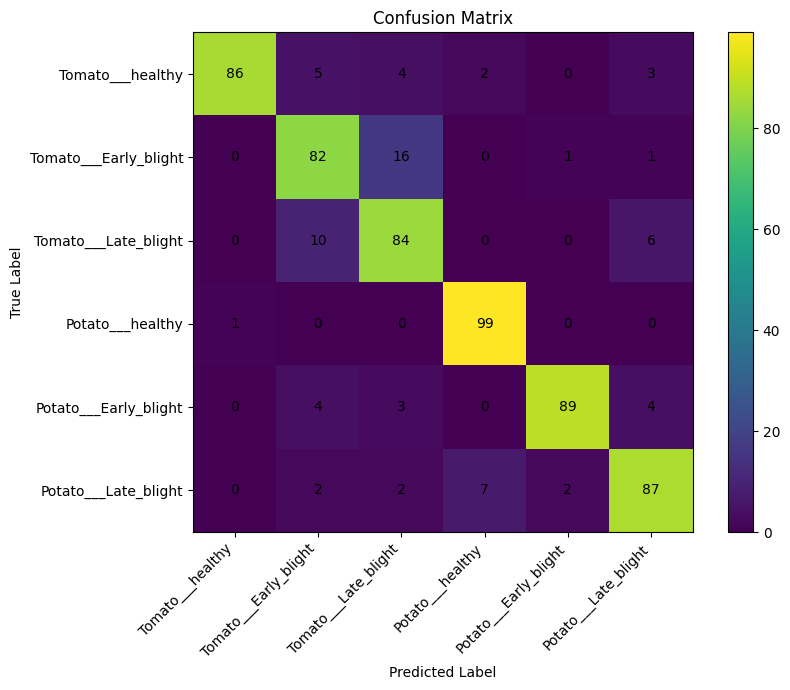

In [22]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

In [23]:
model_path = "plant_disease_resnet18.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names
}, model_path)

print("Model saved successfully as:", model_path)

Model saved successfully as: plant_disease_resnet18.pth


In [24]:
checkpoint = torch.load(model_path, map_location=device)

loaded_class_names = checkpoint["class_names"]

loaded_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = loaded_model.fc.in_features
loaded_model.fc = nn.Linear(num_features, len(loaded_class_names))

loaded_model.load_state_dict(checkpoint["model_state_dict"])

loaded_model = loaded_model.to(device)
loaded_model.eval()

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [25]:
def predict_plant_disease(image_path, model, class_names):
    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0)
    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)

    predicted_label = class_names[predicted_class.item()]
    confidence_score = confidence.item() * 100

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence_score:.2f}%")
    plt.show()

    print("Predicted Disease:", predicted_label)
    print("Confidence:", round(confidence_score, 2), "%")


Test Image: 1
Actual Class: Tomato___Early_blight


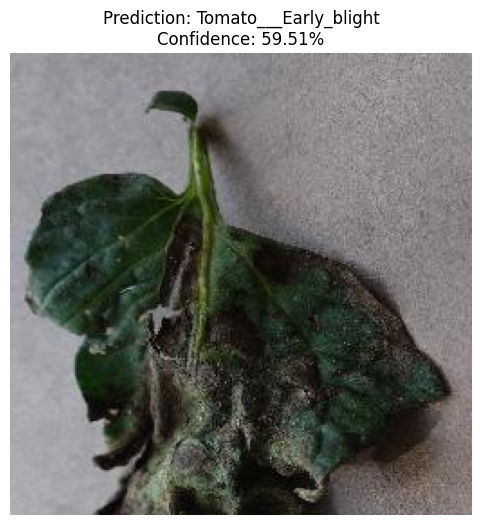

Predicted Disease: Tomato___Early_blight
Confidence: 59.51 %

Test Image: 2
Actual Class: Potato___healthy


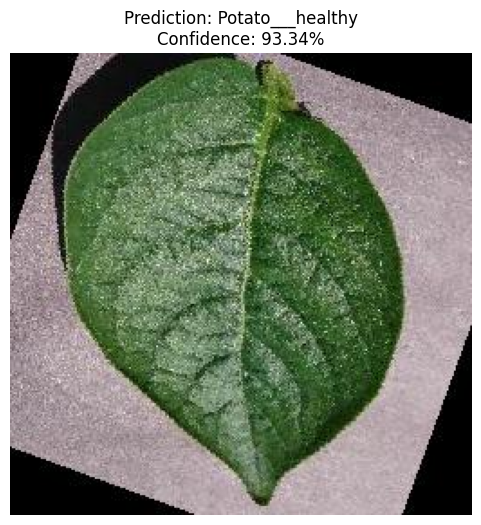

Predicted Disease: Potato___healthy
Confidence: 93.34 %

Test Image: 3
Actual Class: Tomato___Early_blight


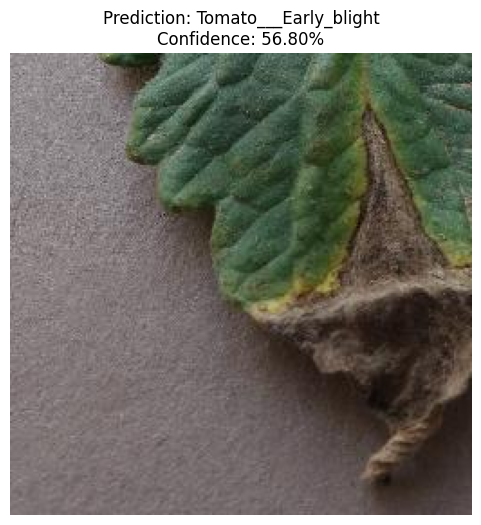

Predicted Disease: Tomato___Early_blight
Confidence: 56.8 %

Test Image: 4
Actual Class: Potato___Late_blight


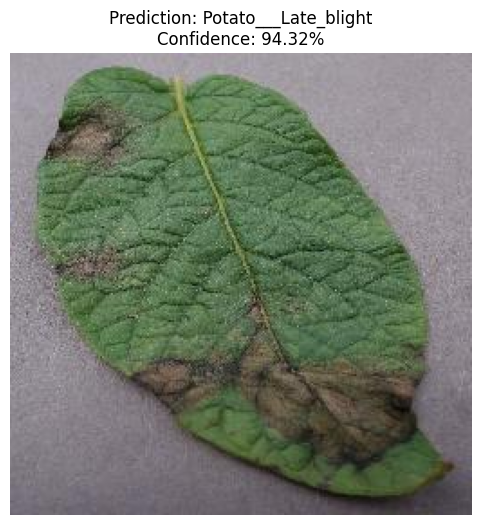

Predicted Disease: Potato___Late_blight
Confidence: 94.32 %

Test Image: 5
Actual Class: Potato___Late_blight


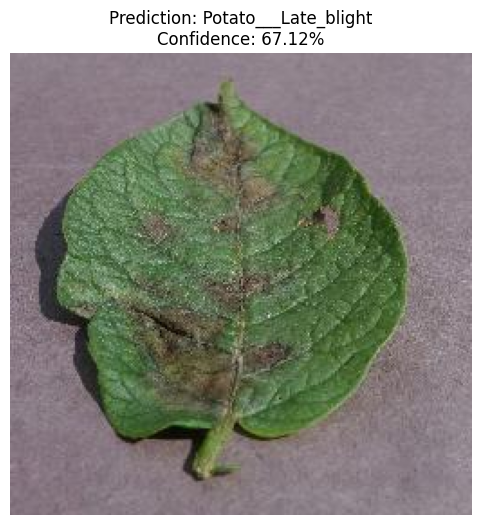

Predicted Disease: Potato___Late_blight
Confidence: 67.12 %

Test Image: 6
Actual Class: Tomato___Late_blight


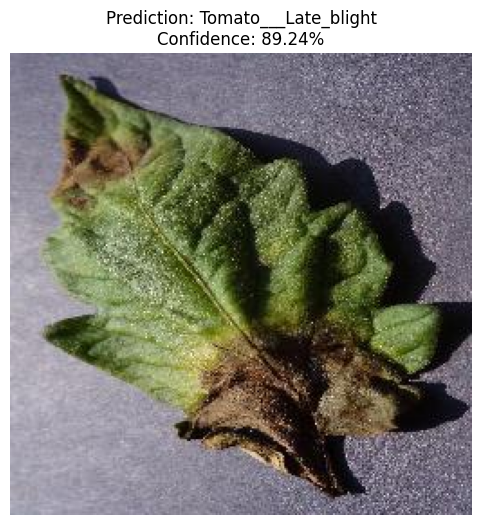

Predicted Disease: Tomato___Late_blight
Confidence: 89.24 %


In [27]:
import random

# Predict 6 random validation images
for i in range(6):
    random_index = random.randint(0, len(valid_dataset.samples) - 1)

    image_path, true_label = valid_dataset.samples[random_index]

    print("\n==============================")
    print("Test Image:", i + 1)
    print("Actual Class:", class_names[true_label])
    print("==============================")

    predict_plant_disease(
        image_path,
        loaded_model,
        loaded_class_names
    )

In [28]:
files.download("plant_disease_resnet18.pth")
files.download("loss_curve.png")
files.download("accuracy_curve.png")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>